IMPORTS AND LOAD DATA

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
ratings = pd.read_csv('/Users/mac/Desktop/MLOps/movie-recommender-mle/data/raw/ml-25m/ratings.csv')
movies = pd.read_csv('/Users/mac/Desktop/MLOps/movie-recommender-mle/data/raw/ml-25m/movies.csv')
tags = pd.read_csv('/Users/mac/Desktop/MLOps/movie-recommender-mle/data/raw/ml-25m/tags.csv')

print(f"Ratings shape: {ratings.shape}")
print(f"Movies shape: {movies.shape}")
print(f"Tags shape: {tags.shape}")

Ratings shape: (25000095, 4)
Movies shape: (62423, 3)
Tags shape: (1093360, 4)


EXPLORING RATINGS

   userId  movieId  rating   timestamp
0       1      296     5.0  1147880044
1       1      306     3.5  1147868817
2       1      307     5.0  1147868828
3       1      665     5.0  1147878820
4       1      899     3.5  1147868510

Rating distribution:
rating
0.5     393068
1.0     776815
1.5     399490
2.0    1640868
2.5    1262797
3.0    4896928
3.5    3177318
4.0    6639798
4.5    2200539
5.0    3612474
Name: count, dtype: int64


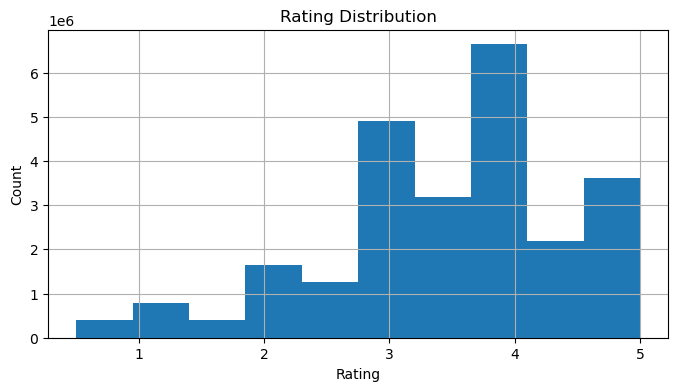

In [5]:
print(ratings.head())
print("\nRating distribution:")
print(ratings['rating'].value_counts().sort_index())

# Plot rating distribution
plt.figure(figsize=(8,4))
ratings['rating'].hist(bins=10)
plt.title('Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

USER ACTIVITY DISTRIBUTION

Avg ratings per user: 153.8
Median ratings per user: 71.0
Most active user: 32202 ratings


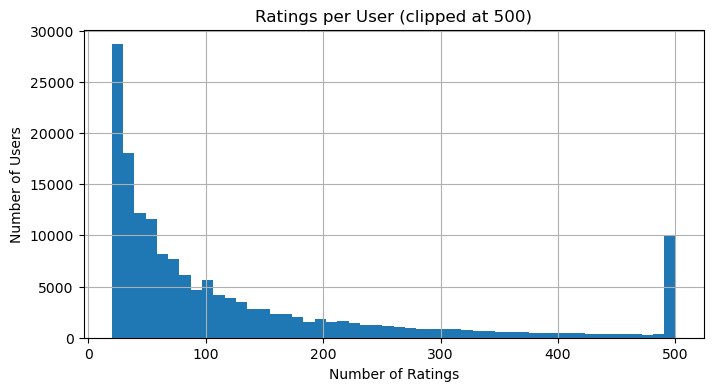

In [6]:
user_activity = ratings.groupby('userId').size()

print(f"Avg ratings per user: {user_activity.mean():.1f}")
print(f"Median ratings per user: {user_activity.median():.1f}")
print(f"Most active user: {user_activity.max()} ratings")

plt.figure(figsize=(8,4))
user_activity.clip(upper=500).hist(bins=50)
plt.title('Ratings per User (clipped at 500)')
plt.xlabel('Number of Ratings')
plt.ylabel('Number of Users')
plt.show()

MOVIE POPULARITY DISTRIBUTION

Avg ratings per movie: 423.4
Movies with only 1 rating: 10298


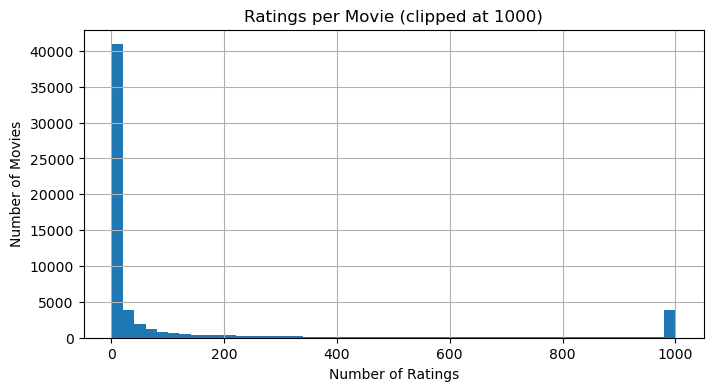

In [7]:
movie_popularity = ratings.groupby('movieId').size()

print(f"Avg ratings per movie: {movie_popularity.mean():.1f}")
print(f"Movies with only 1 rating: {(movie_popularity == 1).sum()}")

plt.figure(figsize=(8,4))
movie_popularity.clip(upper=1000).hist(bins=50)
plt.title('Ratings per Movie (clipped at 1000)')
plt.xlabel('Number of Ratings')
plt.ylabel('Number of Movies')
plt.show()

GENRE ANALYSIS

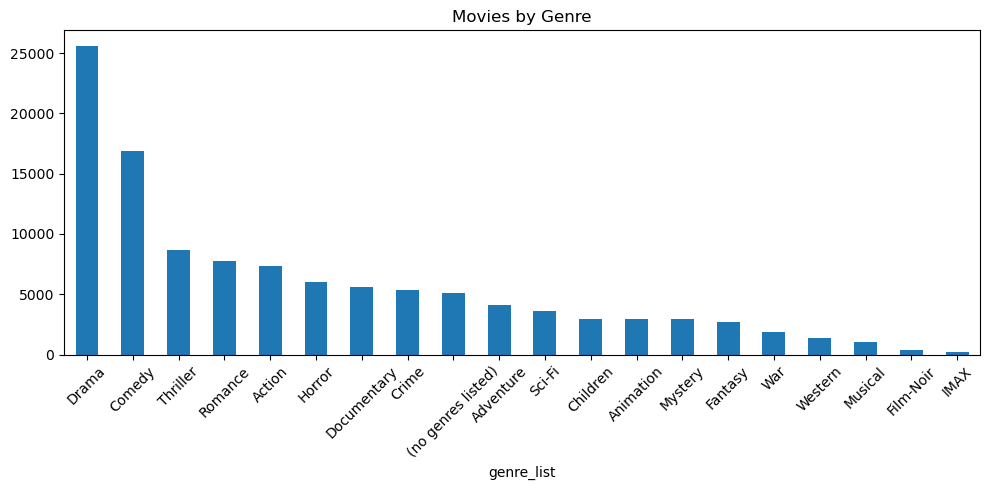

In [8]:
# Explode genres
movies['genre_list'] = movies['genres'].str.split('|')
genre_counts = movies.explode('genre_list')['genre_list'].value_counts()

plt.figure(figsize=(10,5))
genre_counts.plot(kind='bar')
plt.title('Movies by Genre')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()